### RBF Distance

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d
from matplotlib.patches import FancyArrowPatch

In [3]:
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return min(zs)

/tmp/ipykernel_2790315/1510933366.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


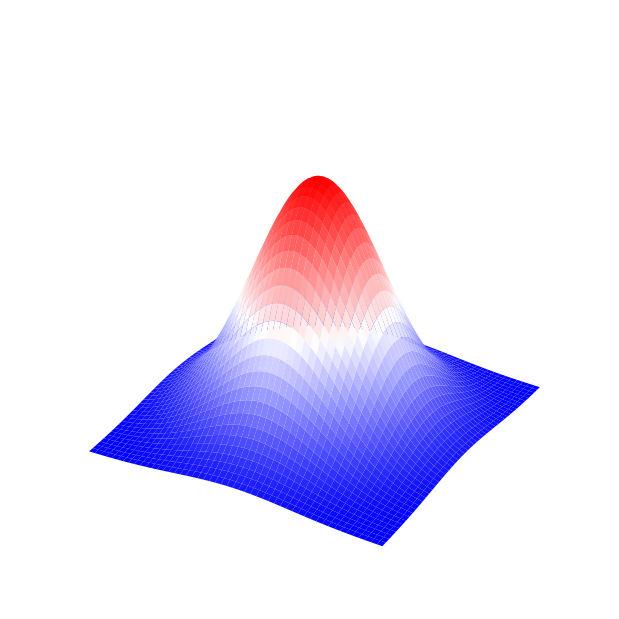

In [12]:
%matplotlib inline
x = np.linspace(-10, 10, 500)
y = np.linspace(-10, 10, 500)
x, y = np.meshgrid(x, y)

font_dict = {
    'color': 'black',
    'weight': 'bold',
    'size': 24,
}

w0 = 4
gaussian0 = 1 * np.exp(-((pow(x, 2) + pow(y, 2)) / (2 * pow(w0, 2))))

# w1 = 1
# gaussian1 = 0.75 * np.exp(-((pow(x+9, 2) + pow(y+5, 2)) / (2 * pow(w1, 2))))

# w2 = 1.5
# gaussian2 = 0.6 * np.exp(-((pow(x+7, 2) + pow(y-8, 2)) / (2 * pow(w2, 2))))

# w3 = 2.7
# gaussian3 = 0.35 * np.exp(-((pow(x+4, 2) + pow(y+1, 2)) / (2 * pow(w3, 2))))

# w4 = 2.0
# g_x = 0.5 * np.exp(-((pow(x-5, 2) + pow(y+8, 2)) / (2 * pow(w4, 2))))

# gaussian = gaussian0 + gaussian1 + gaussian2 + gaussian3 + g_x

gaussian = gaussian0
# plt.figure()
# plt.imshow(gaussian)

fig = plt.figure(figsize=(8, 6))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
ax.set_axis_off()

ax.plot_surface(x, y, gaussian, cmap="bwr")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# arrow11 = Arrow3D([4, 6], [3, -8], [0.65, 0.48], mutation_scale=20, lw=3.5, arrowstyle="-|>", color='gray')
# arrow12 = Arrow3D([6, 4], [-8, 3], [0.48, 0.65], mutation_scale=20, lw=3.5, arrowstyle="-|>", color='gray')
# ax.add_artist(arrow11)
# ax.add_artist(arrow12)

# arrow21 = Arrow3D([-9, 3.5], [-5, -8], [0.5, 0.43], mutation_scale=20, lw=3.5, arrowstyle="-|>", color='gray')
# arrow22 = Arrow3D([3.5, -9], [-8, -5], [0.43, 0.5], mutation_scale=20, lw=3.5, arrowstyle="-|>", color='gray')
# ax.add_artist(arrow21)
# ax.add_artist(arrow22)

# arrow31 = Arrow3D([-7, 5], [8, -8], [0.49, 0.57], mutation_scale=20, lw=3.5, arrowstyle="-|>", color='gray')
# arrow32 = Arrow3D([5, -7], [-8, 8], [0.57, 0.49], mutation_scale=20, lw=3.5, arrowstyle="-|>", color='gray')
# ax.add_artist(arrow31)
# ax.add_artist(arrow32)

# arrow41 = Arrow3D([-4, 4], [-1, -8], [0.33, 0.48], mutation_scale=20, lw=3.5, arrowstyle="-|>", color='gray')
# arrow42 = Arrow3D([4, -4], [-8, -1], [0.48, 0.33], mutation_scale=20, lw=3.5, arrowstyle="-|>", color='gray')
# ax.add_artist(arrow41)
# ax.add_artist(arrow42)

# ax.text(3.5, 1.5, 0.92, "Center 1", fontdict=font_dict)
# ax.text(-10.5, -6.5, 0.77, "Center 2", fontdict=font_dict)
# ax.text(-8.5, 6.5, 0.62, "Center 3", fontdict=font_dict)
# ax.text(-5.5, -2.5, 0.37, "Center 4", fontdict=font_dict)
# ax.text(5.5, -10, 0.58, "X", fontdict=font_dict)

plt.tight_layout()
plt.savefig("./RBF_Dist_diagram.png", format='png', transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.0)